## We will learn in this Module:  

- With given Dataset - Data processing  
- Building ML model, saving in .pkl format  
- ML APIs, Loading model, make predections

input - Postman  
output - Json file predection

## Data Preprocessing for Machine Learning
- Topics :
    - 1. Collecting the Dataset
    - 2. Understanding the Data Structure and Features
    - 3. Cleaning the Data
         - a. Handling missing values
         - b. Removing duplicates
         
    - 4. Exploratory Data Analysis (EDA)
         - a. Visualizing distributions
         - b. Correlation analysis

- check the folder dataset 

In [2]:
import pandas as pd                              #collecting dataset
df = pd.read_csv("Dataset/babies.csv")
df.head()

,case,bwt,gestation,parity,age,height,weight,smoke
0,1,120,284.0,0,27.0,62.0,100.0,0.0
1,2,113,282.0,0,33.0,64.0,135.0,0.0
2,3,128,279.0,0,28.0,64.0,115.0,1.0
3,4,123,NaN,0,36.0,69.0,190.0,0.0
4,5,108,282.0,0,23.0,67.0,125.0,1.0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1236 entries, 0 to 1235
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   case       1236 non-null   int64  
 1   bwt        1236 non-null   int64  
 2   gestation  1223 non-null   float64
 3   parity     1236 non-null   int64  
 4   age        1234 non-null   float64
 5   height     1214 non-null   float64
 6   weight     1200 non-null   float64
 7   smoke      1226 non-null   float64
dtypes: float64(5), int64(3)
memory usage: 77.4 KB


In [4]:
df.describe()        #understanding the data

,case,bwt,gestation,parity,age,height,weight,smoke
count,1236.000000,1236.000000,1223.000000,1236.000000,1234.000000,1214.000000,1200.000000,1226.000000
mean,618.500000,119.576861,279.338512,0.254854,27.255267,64.047776,128.625833,0.394780
std,356.946775,18.236452,16.027693,0.435956,5.781405,2.533409,20.971862,0.489003
min,1.000000,55.000000,148.000000,0.000000,15.000000,53.000000,87.000000,0.000000
25%,309.750000,108.750000,272.000000,0.000000,23.000000,62.000000,114.750000,0.000000
50%,618.500000,120.000000,280.000000,0.000000,26.000000,64.000000,125.000000,0.000000
75%,927.250000,131.000000,288.000000,1.000000,31.000000,66.000000,139.000000,1.000000
max,1236.000000,176.000000,353.000000,1.000000,45.000000,72.000000,250.000000,1.000000


## #clean the data:
## #missing values/ Duplicate values - Handaling values

In [5]:
# finding the missing values
df.isnull().sum()

case          0
bwt           0
gestation    13
parity        0
age           2
height       22
weight       36
smoke        10
dtype: int64

In [6]:
## removing the missing value
df.dropna(inplace=True)

In [7]:
df.isnull().sum()

case         0
bwt          0
gestation    0
parity       0
age          0
height       0
weight       0
smoke        0
dtype: int64

In [ ]:
## duplicate values
print(df.duplicated().sum())

0


## Exploratory Data Analysis (EDA)

In [10]:
import matplotlib.pyplot as plt

In [12]:
df.columns

Index(['case', 'bwt', 'gestation', 'parity', 'age', 'height', 'weight',
       'smoke'],
      dtype='str')

In [13]:
df.drop(columns=['case'], inplace=True) #columns -list of columns and inplace= True means wants to make changes in my original data

In [16]:
df.columns

Index(['bwt', 'gestation', 'parity', 'age', 'height', 'weight', 'smoke'], dtype='str')

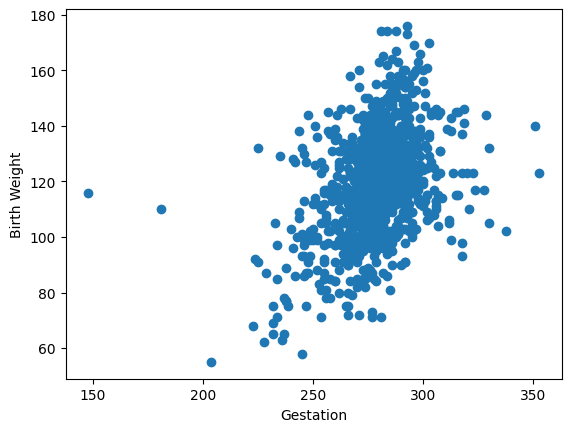

In [18]:
plt.scatter(df['gestation'], df['bwt']) #scatter takes x value and y value
plt.xlabel("Gestation")
plt.ylabel("Birth Weight")
plt.show()

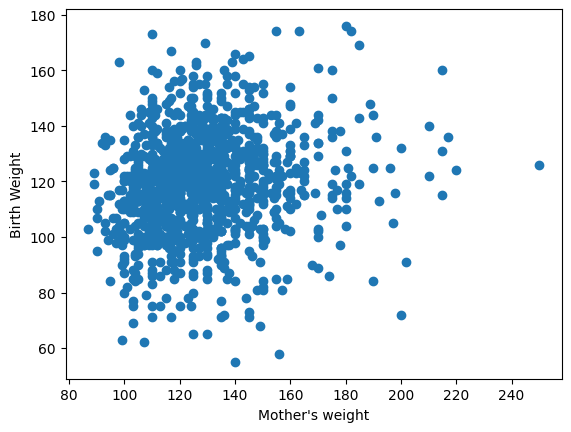

In [19]:
plt.scatter(df['weight'], df['bwt']) #scatter takes x value and y value
plt.xlabel("Mother's weight")
plt.ylabel("Birth Weight")
plt.show()

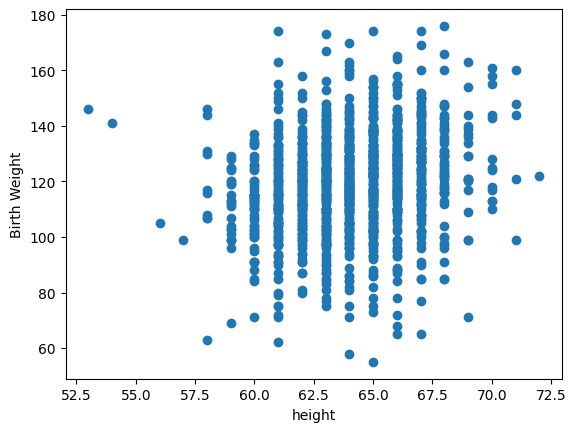

In [ ]:
plt.scatter(df['height'], df['bwt']) #scatter takes x value and y value
plt.xlabel("height")
plt.ylabel("Birth Weight")
plt.show()               #theres no linear relation between the height as there was in previous images

In [ ]:
df['smoke'].unique() #smoke is abinary number so unique can be use to determine if mother is smoker or not i.e. it gives 2 values

array([0., 1.])

In [23]:
df["smoke"].value_counts() # it will count the no. of mothers who are smoker and who are not

smoke
0.0    715
1.0    459
Name: count, dtype: int64

In [ ]:
df["smoke"].value_counts(normalize=True)*100 # gives the percentage
#normalize=True gives you a decimal (proportion), It takes each count and divides it by the total number of rows:{Count}/{Total Rows}, multiplying the entire result by 100 converts to percentage

smoke
0.0    60.902896
1.0    39.097104
Name: proportion, dtype: float64

In [26]:
df['parity'].unique() #first time giving the birth or multiple time giving the birth

array([0, 1])

In [ ]:
df['parity'].value_counts() # 866 first time , 308 - multiple times

parity
0    866
1    308
Name: count, dtype: int64

In [ ]:
## corelation matrix
df.corr()       #eg. relation of btw with gestation, parrity etc, +ve means strong relation, -ve means weak relation

,bwt,gestation,parity,age,height,weight,smoke
bwt,1.000000,0.407543,-0.043908,0.026983,0.203704,0.155923,-0.246800
gestation,0.407543,1.000000,0.080916,-0.053425,0.070470,0.023655,-0.060267
parity,-0.043908,0.080916,1.000000,-0.351041,0.043543,-0.096362,-0.009599
age,0.026983,-0.053425,-0.351041,1.000000,-0.006453,0.147322,-0.067772
height,0.203704,0.070470,0.043543,-0.006453,1.000000,0.435287,0.017507
weight,0.155923,0.023655,-0.096362,0.147322,0.435287,1.000000,-0.060281
smoke,-0.246800,-0.060267,-0.009599,-0.067772,0.017507,-0.060281,1.000000
